In [8]:
# Colab setup -- installs SoftMobility when running on Google Colab.
# Tip: For large simulations, switch to a GPU runtime first:
#   Runtime → Change runtime type → T4 GPU (free)
# Then re-run this cell to install the CUDA-enabled JAX.
try:
    import shutil

    import google.colab  # noqa: F401

    if shutil.which("nvidia-smi"):
        %pip install -q -U softmobility "jax[cuda12]"
    else:
        %pip install -q softmobility
except ImportError:
    pass

# Example 03. Rotating elastic filament

A flexible filament is anchored at one end on a clamp offset by $\delta_0$ from a rotation axis, and the clamp is forced to rotate at angular rate $\zeta$ around that axis with a fixed tilt $\psi$ relative to it.
Viscous drag drives the chain into a steady, body-frame chiral shape that wraps onto the rotation axis as the dimensionless rotation rate $\mathrm{Sp}^4$ increases.
We reproduce the first four panels of this canonical setup of Coq, du Roure, Marthelot, Bartolo & Fermigier (2008, 2009) at $\mathrm{Sp}^4 = 0.5, 5, 15, 35$, with offset $\delta_0 / L = 0.05$.

**Why this is a clamped-anchor problem.** The body's six-component lab pose is *prescribed* by the actuator, so the body's six-component velocity $\mathbf{v}_0 = [\mathbf{u}_0, \boldsymbol{\omega}_0]$ becomes an input of the soft mobility equation rather than an output.
The six-component reaction force the anchor exerts on sphere 0, $\mathbf{f}_0 = [\mathbf{F}_0, \mathbf{T}_0]$, is the corresponding new unknown.
The mobility equation is partitioned (Appendix C of the companion paper): the top six rows form a $6\times 6$ linear system for $\mathbf{f}_0$ given $\mathbf{v}_0$; the bottom $N_Q$ rows then yield the deformation rate $\dot{\mathbf{Q}}$.

The library exposes this via [`FlowBodyRollout.rollout_clamped_anchor`](../classes/solver.py), which takes the actuator's lab-frame **position** and **velocity** as two callables of $t$ plus the body's initial orientation, and returns the trajectory of the deformation DOFs together with the reaction $\mathbf{f}_0$ at every step.
The body's Rodrigues vector is integrated forward internally with the same Bortz/RK4 scheme as the standard rollout, so it stays singularity-free for unbounded rotations.

In [9]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import softmobility as sm
from softmobility.classes import figstyle

figstyle.apply()
FIGDIR = "figures"

np.set_printoptions(precision=3, suppress=True)

## 1. Filament geometry

We model the filament as $N=10$ beads of radius $a=1$ connected by rigid bonds of length $2a$.
Bending modulus $B=30$, fluid viscosity $\mu=1$.
Following Coq, du Roure, Marthelot, Bartolo & Fermigier (2009), the slender-body transverse drag per unit length is
$$
\mu_\perp = \frac{4\pi\mu}{\ln(L/a) + 1/2},
$$
and the Sperm number is
$$
\mathrm{Sp} = \frac{L}{L_\omega}, \qquad
L_\omega = \left(\frac{B}{\mu_\perp\,\omega}\right)^{1/4},
$$
so $\mathrm{Sp}^4 = L^4\,\mu_\perp\,\omega / B$ and the prescribed angular frequency is $\omega = \mathrm{Sp}^4\,B / (L^4\,\mu_\perp)$, with $L = (N-1)\,2a$.
Tilt angle $\psi = 15^\circ$ from the rotation axis (Coq's experimental value).
Geometry and elasticity are held fixed across the four $\mathrm{Sp}^4$ runs; only $\omega$ changes.

**Note.** Here, we use the conventional definition of the Sperm number.
In Coq et al. (2008,2009), they use a different convention: $\mathrm{Sp}_{\rm Coq} = \mathrm{Sp}^4$)

In [10]:
N = 10
a = 1.0
mu = 1.0
bending_rigidity = 30.0
psi = 15 / 180 * np.pi  # 15° tilt

L = (N - 1) * 2 * a
mu_perp = 4 * np.pi * mu / (np.log(L / a) + 0.5)  # Slender-body
tau_el = mu_perp * L**4 / bending_rigidity  # elastic relaxation time
print(f"L = {L:.1f}, B = {bending_rigidity}, mu_perp = {mu_perp:.3f}, tau_el = {tau_el:.1f}")

fiber = sm.FlexibleFiber(
    n_beads=N,
    radius=a,
    bending_rigidity=bending_rigidity,
    mass=0.0,
    planar=False,
)
rollout = sm.FlowBodyRollout(
    soft_body=fiber,
    flow=sm.no_flow(),
    input_map={"gravity": sm.gravity_field(g=0.0)},
)
print(f"FlexibleFiber: Nspheres = {fiber.Nspheres}, Ndof = {fiber.Ndof}")

L = 18.0, B = 30.0, mu_perp = 3.706, tau_el = 12969.7
FlexibleFiber: Nspheres = 10, Ndof = 18


## 2 — Anchor pose and velocity

The clamp is mounted on a rotating arm offset from the spin axis by $\delta_0 = 0.05\,L$, so its lab-frame trajectory is the circle $\mathbf{r}_0(t) = (0,\,\delta_0 \cos\omega t,\,\delta_0 \sin\omega t)$.
The lab-frame angular velocity is the constant $\boldsymbol{\omega}_{\rm lab} = \omega\,\mathbf{e}_1$, and the translational velocity is the rigid-body $\mathbf{u}_0(t) = \boldsymbol{\omega}\times\mathbf{r}_0(t)$.

The body's initial orientation tilts $\mathbf{E}_1$ by $\psi$ around $\mathbf{e}_3$.

The method `rollout_clamped_anchor` integrates the body's Rodrigues vector forward via Bortz from the supplied $\boldsymbol{\omega}_0(t)$ (no singular axis-angle reconstruction is needed).

In [11]:
delta0 = 0.05 * L


def make_anchor_position_fn(omega, t0=0.0):
    """Anchor orbits the lab x-axis at radius delta0 in the y-z plane.

    `t0` offsets the orbital phase so a chunked restart continues the orbit
    instead of jumping back to phase 0.
    """

    def anchor_position_fn(t):
        tt = t + t0
        return jnp.array(
            [
                0.0,
                delta0 * jnp.cos(omega * tt),
                delta0 * jnp.sin(omega * tt),
            ]
        )

    return anchor_position_fn


def make_anchor_velocity_fn(omega, t0=0.0):
    """Six-component lab velocity of the orbiting anchor: u_lab = omega x r."""
    omega_lab = jnp.array([omega, 0.0, 0.0])

    def anchor_velocity_fn(t):
        tt = t + t0
        u_lab = jnp.array(
            [
                0.0,
                -delta0 * omega * jnp.sin(omega * tt),
                delta0 * omega * jnp.cos(omega * tt),
            ]
        )
        return jnp.concatenate([u_lab, omega_lab])

    return anchor_velocity_fn


INIT_ORIENTATION = jnp.array([0.0, 0.0, psi])

## 3. Run one $\mathrm{Sp}$ to show the API

The deformation $\mathbf{Q}$ reaches a body-frame steady state on the elastic timescale $\tau_{\rm el} = \mu_\perp\,L^4 / B$, the same for all $\mathrm{Sp}^4$ values; only the lab-frame rotation period $2\pi/\omega$ changes.
The integrator step is $\Delta t = 0.2\,(2a)^4\mu/B$, set by the *bond* scale — four times the conservative default of the existing `rollout`, and well within RK4 stability for the bending modes.
A full $5\,\tau_{\rm el}$ run is then $6\times 10^5$ steps, and `rollout_clamped_anchor` returns the whole trajectory.

We integrate in chunks rather than in one shot.
Each chunk keeps only its final $(\boldsymbol{\theta}_0, \mathbf{Q})$ instead of the full trajectory, and the chunk driver is `jax.jit`-compiled **once** — with $\omega$, the chunk start time $t_0$ and the restart state as traced arguments — then reused across chunks and across all four $\mathrm{Sp}^4$ values.
The steadiness diagnostic $\max|\dot{\mathbf{Q}}|\,\tau_{\rm el}$ is printed per chunk and the loop stops as soon as it drops below `steady_tol`, which happens near $\tau_{\rm el}$ rather than at $5\,\tau_{\rm el}$: the residual decays exponentially at a few per $\tau_{\rm el}$, so the tolerance $10^{-2}$ pins the shape to $\sim10^{-3}$ rad, well below anything visible in the figure.
Both together cut the run from minutes to seconds per $\mathrm{Sp}^4$ value.

In [12]:
@partial(jax.jit, static_argnames=("n_steps",))
def run_chunk(omega, t0, orientation, dofs, dt, n_steps):
    """One jitted chunk of the clamped-anchor rollout, restarted at time t0."""
    return rollout.rollout_clamped_anchor(
        dt=dt,
        n_steps=n_steps,
        anchor_position_fn=make_anchor_position_fn(omega, t0),
        anchor_velocity_fn=make_anchor_velocity_fn(omega, t0),
        init_orientation=orientation,
        init_dofs=dofs,
    )


def integrate_to_steady_state(
    sp4,
    n_tau=5.0,
    dt_safety=0.2,
    n_chunks=25,
    steady_tol=1e-2,
    init_dofs=None,
    verbose=True,
):
    """Integrate to the body-frame steady shape, chunk by chunk, stopping early.

    `init_dofs` warm-starts from a previously converged shape; the orientation
    always restarts at INIT_ORIENTATION, which is the phase-0 pose consistent
    with any steady Q.
    """
    omega = sp4 * bending_rigidity / (L**4 * mu_perp)
    dt = dt_safety * (2 * a) ** 4 * mu / bending_rigidity
    chunk_steps = int(np.ceil(n_tau * tau_el / dt / n_chunks))
    orientation = INIT_ORIENTATION
    dofs = jnp.zeros(fiber.Ndof) if init_dofs is None else jnp.asarray(init_dofs)
    f_0_last = np.zeros(6)
    residual = np.inf

    for j in range(n_chunks):
        _, orientations, dofs_traj, f_0 = run_chunk(
            omega, j * chunk_steps * dt, orientation, dofs, dt, chunk_steps
        )
        dofs_traj.block_until_ready()
        residual = float(np.max(np.abs(np.asarray(dofs_traj[-1] - dofs_traj[-2]))) / dt * tau_el)
        orientation, dofs = orientations[-1], dofs_traj[-1]
        f_0_last = np.asarray(f_0[-1])
        if verbose:
            print(
                f"  chunk {j + 1:2d}/{n_chunks}: t = {(j + 1) * chunk_steps * dt / tau_el:.2f} tau_el, "
                f"max|Q| = {float(np.max(np.abs(dofs))):.3e}, "
                f"max|Q_dot|*tau_el = {residual:.2e}",
                flush=True,
            )
        if residual < steady_tol:
            break

    return omega, np.asarray(dofs), f_0_last, residual


omega, dofs_steady, f_0_steady, residual = integrate_to_steady_state(5.0)
print(f"Sp**4 = 5:  omega = {omega:.3e}")
print(f"final max|Q|            = {np.max(np.abs(dofs_steady)):.3e}")
print(f"final max|f_0|          = {np.max(np.abs(f_0_steady)):.3e}")
print(f"final max|Q_dot|*tau_el = {residual:.3e}  (steady state if << 1)")

  chunk  1/25: t = 0.20 tau_el, max|Q| = 2.184e-01, max|Q_dot|*tau_el = 4.37e-01
  chunk  2/25: t = 0.40 tau_el, max|Q| = 2.314e-01, max|Q_dot|*tau_el = 1.11e-01
  chunk  3/25: t = 0.60 tau_el, max|Q| = 2.236e-01, max|Q_dot|*tau_el = 2.72e-02
  chunk  4/25: t = 0.80 tau_el, max|Q| = 2.209e-01, max|Q_dot|*tau_el = 5.44e-03
Sp**4 = 5:  omega = 3.855e-04
final max|Q|            = 2.209e-01
final max|f_0|          = 9.148e-01
final max|Q_dot|*tau_el = 5.436e-03  (steady state if << 1)


## 4. Lab-frame snapshots over one rotation period

At steady state the chain has a fixed body-frame shape $\mathbf{Q}_\star$; in the lab frame this shape rotates rigidly around $\mathbf{e}_x$, with the clamp orbiting at radius $\delta_0$.
The lab-frame chain at phase $\omega t$ is therefore reconstructed as $\mathbf{r}_0(t) + R_x(\omega t)\,R_z(\psi)\,\mathbf{X}_{\rm body}$.

The figure is a flat side view on the $(y, x)$ plane, laid out like the experimental photographs: rotation axis vertical as a dotted guide, anchor at the top, fiber hanging down, axes off.
`n_phases` snapshots over one rotation period are superimposed as black centerlines (default 10; pass `n_phases=16` etc. to refine), and the beads of one phase are drawn behind them at true radius $a$, with the red contour and light-red fill used for beads in example 04, so the discretisation is visible.
Passing `bounds` forces a shared scale across panels; the demo below leaves it `None` and autoscales, and the $\mathrm{Sp}^4$ scan of §5 recomputes all four panels on a common box.

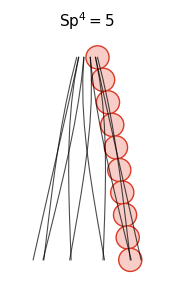

In [13]:
def _Rx(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def _Rz(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def body_frame_positions(dofs):
    """Body-frame bead positions (Nspheres, 3) for the given dofs."""
    out = np.zeros((fiber.Nspheres, 3))
    design_np = np.asarray(fiber.design_defaults)
    t_dummy = np.array([0.0])
    for i in range(fiber.Nspheres):
        out[i] = np.asarray(fiber.spheres[i].position(dofs, design_np, t_dummy))
    return out


def strobe_chains(dofs_steady, omega, n_phases=10):
    """Lab-frame chains (n_phases, Nspheres, 3) over one rotation period."""
    body_pos = body_frame_positions(np.asarray(dofs_steady))
    times = np.linspace(0.0, 2 * np.pi / float(omega), n_phases, endpoint=False)
    R_z_psi = _Rz(psi)
    anchors = np.stack(
        [np.array([0.0, delta0 * np.cos(omega * t), delta0 * np.sin(omega * t)]) for t in times],
        axis=0,
    )
    return np.stack(
        [anc + body_pos @ (_Rx(omega * t) @ R_z_psi).T for t, anc in zip(times, anchors, strict=True)],
        axis=0,
    )


def chain_bounds(chain_sets, pad=2.0 * a):
    """Shared ((y_lo, y_hi), (x_lo, x_hi)) box for one or more chain sets."""
    points = np.concatenate([np.asarray(c).reshape(-1, 3) for c in chain_sets], axis=0)
    return (
        (points[:, 1].min() - pad, points[:, 1].max() + pad),
        (points[:, 0].min() - pad, points[:, 0].max() + pad),
    )


def draw_sideview(ax, chains, sp4, bounds):
    """Side view on (y, x): rotation axis vertical, anchor at top, fiber down."""
    (y_lo, y_hi), (x_lo, x_hi) = bounds

    # Rotation axis (lab e_x) as a thin dotted guide, spanning the panel.
    # ax.plot([0.0, 0.0], [x_lo, x_hi], color=figstyle.COLORS["black"], linewidth=0.8, linestyle=":")

    # Beads of the first phase at true radius a, behind the centerlines and in
    # the bead style of example 04: red contour, light red fill.
    for bead in chains[0]:
        ax.add_patch(
            plt.Circle(
                (bead[1], bead[0]),
                a,
                edgecolor=figstyle.COLORS["red"],
                facecolor=figstyle.COLORS["red_25"],
                linewidth=1.0,
                zorder=0,
            )
        )

    # Stroboscoped centerlines, one per phase, on top of the beads.
    for chain in chains:
        ax.plot(chain[:, 1], chain[:, 0], color=figstyle.COLORS["black"], linewidth=0.8, alpha=0.7)

    ax.set_title(rf"$\mathrm{{Sp}}^4 = {sp4:g}$")
    ax.set_xlim(y_lo, y_hi)
    ax.set_ylim(x_hi, x_lo)  # inverted: anchor at the top
    ax.set_aspect("equal")
    ax.set_axis_off()


def render_panel(chains, sp4, save_name, bounds=None):
    """Draw one side-view panel on `bounds` (autoscaled when None) and save it."""
    if bounds is None:
        bounds = chain_bounds([chains])
    (y_lo, y_hi), (x_lo, x_hi) = bounds
    fig, ax = figstyle.figure(size="third", aspect=(y_hi - y_lo) / (x_hi - x_lo))
    draw_sideview(ax, chains, sp4, bounds)
    figstyle.save(fig, save_name, figdir=FIGDIR)
    return fig


def make_figure(sp4, dofs_steady, omega, save_name, n_phases=10, bounds=None):
    """Strobe the steady shape over one rotation period, then render it."""
    return render_panel(strobe_chains(dofs_steady, omega, n_phases=n_phases), sp4, save_name, bounds)


fig_demo = make_figure(5.0, dofs_steady, omega, "fig_rotating_demo")

## 5 — $\mathrm{Sp}$ scan: reproducing experimental results

Repeating the rollout for $\mathrm{Sp}^4 \in \{0.5, 5, 15, 35\}$ reproduces the first four panels of Coq et al. (2009) Fig. 4, with the offset clamp $\delta_0/L = 0.05$:

* **$\mathrm{Sp}^4 = 0.5$**: chain essentially straight, tilted by $\psi$, traces a clean cone.
* **$\mathrm{Sp}^4 = 5$**: visible bending; the cone widens at the tip.
* **$\mathrm{Sp}^4 = 15$**: the chain noticeably wraps; the swept volume is a chiral leaf.
* **$\mathrm{Sp}^4 = 35$**: tighter wrapping onto the rotation axis.

Higher experimental $\mathrm{Sp}^4$ values (200, 1500, 3500) lie outside the linearised-bending regime of `FlexibleFiber` (joint angles $\gtrsim \pi/4$) and are not reproduced here.

The scan runs in increasing $\mathrm{Sp}^4$ order and warm-starts each case from the previous converged $\mathbf{Q}_\star$.
The steady body-frame shape is a continuous function of $\mathrm{Sp}^4$, so this is a continuation, and it shortens every transient after the first — the same trick as the rigidity sweep of example 02.
The $\mathrm{Sp}^4 = 5$ case is taken straight from §3 instead of being integrated a second time.
The four panels are then drawn on a **common** box computed from all four cases, so the wrapping sequence can be read across the figures; each is saved as `figures/fig_rotating_sp4_{0p5|5|15|35}.pdf`.

Sp**4 = 0.5
  chunk  1/25: t = 0.20 tau_el, max|Q| = 2.428e-02, max|Q_dot|*tau_el = 5.39e-02
  chunk  2/25: t = 0.40 tau_el, max|Q| = 2.984e-02, max|Q_dot|*tau_el = 1.20e-02
  chunk  3/25: t = 0.60 tau_el, max|Q| = 3.107e-02, max|Q_dot|*tau_el = 2.49e-03
  -> omega = 3.855e-05  max|Q| = 3.107e-02  max|f_0| = 1.246e-01  max|Q_dot|*tau_el = 2.491e-03
  -> omega = 3.855e-04  max|Q| = 2.209e-01  max|f_0| = 9.148e-01  max|Q_dot|*tau_el = 5.436e-03
Sp**4 = 15
  chunk  1/25: t = 0.20 tau_el, max|Q| = 4.388e-01, max|Q_dot|*tau_el = 8.26e-01
  chunk  2/25: t = 0.40 tau_el, max|Q| = 3.768e-01, max|Q_dot|*tau_el = 1.87e-01
  chunk  3/25: t = 0.60 tau_el, max|Q| = 3.892e-01, max|Q_dot|*tau_el = 3.99e-02
  chunk  4/25: t = 0.80 tau_el, max|Q| = 3.869e-01, max|Q_dot|*tau_el = 9.06e-03
  -> omega = 1.157e-03  max|Q| = 3.869e-01  max|f_0| = 1.429e+00  max|Q_dot|*tau_el = 9.059e-03
Sp**4 = 35
  chunk  1/25: t = 0.20 tau_el, max|Q| = 4.590e-01, max|Q_dot|*tau_el = 9.35e-01
  chunk  2/25: t = 0.40 tau_el

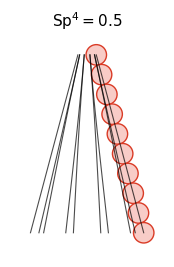

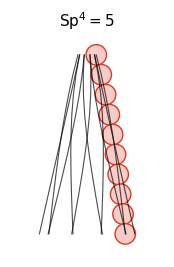

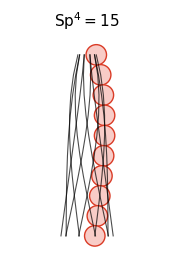

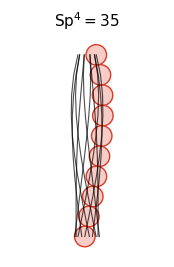

In [14]:
labels = {0.5: "0p5", 5.0: "5", 15.0: "15", 35.0: "35"}
sp4_cases = (0.5, 5.0, 15.0, 35.0)

# Pass 1: converge every case, warm-starting the next from the current shape.
# Sp**4 = 5 is already converged in section 3, so it is reused rather than re-run.
converged = {5.0: (omega, dofs_steady, f_0_steady, residual)}
chains_by_sp4 = {}
warm_dofs = None
for sp4 in sp4_cases:
    if sp4 not in converged:
        print(f"Sp**4 = {sp4:g}")
        converged[sp4] = integrate_to_steady_state(sp4, init_dofs=warm_dofs)
    omega_c, dofs_c, f_0_c, residual_c = converged[sp4]
    warm_dofs = dofs_c
    chains_by_sp4[sp4] = strobe_chains(dofs_c, omega_c)
    fiber.scan_trajectory_for_overlap(dofs_c[None, :])
    print(
        f"  -> omega = {omega_c:.3e}  "
        f"max|Q| = {np.max(np.abs(dofs_c)):.3e}  "
        f"max|f_0| = {np.max(np.abs(f_0_c)):.3e}  "
        f"max|Q_dot|*tau_el = {residual_c:.3e}"
    )

# Pass 2: one common box, then one panel per case.
common_bounds = chain_bounds(chains_by_sp4.values())
for sp4 in sp4_cases:
    render_panel(chains_by_sp4[sp4], sp4, f"fig_rotating_sp4_{labels[sp4]}", bounds=common_bounds)

## Notes

* **Anchor reaction force.** $\mathbf{f}_0$ is the force the external actuator exerts on sphere 0 to enforce the prescribed pose.
  Its component along the rotation axis is the propulsive thrust the filament generates against the actuator (Coq Fig. 5); here it grows monotonically with $\omega$ as expected.
  With the offset clamp ($\delta_0 = 0.05\,L$), $\mathbf{f}_0$ also carries the carriage's centripetal contribution, but at $O(\delta_0/L)$ on top of an already-massless Stokes drag this barely shifts the printed magnitudes.
* **Chunked integration.** `rollout_clamped_anchor` returns the whole trajectory; chunking keeps only each chunk's final state and lets the run stop as soon as $\max|\dot{\mathbf{Q}}|\,\tau_{\rm el}$ falls below tolerance.
  The saving grows fast with $N$: $\tau_{\rm el} = \mu_\perp L^4/B$ scales as $L^4$ while the bond-limited step does not, so at $N=15$ a single-shot $5\,\tau_{\rm el}$ run would be $3.1\times10^6$ steps and several hundred MB.
  One side effect: inside `jax.jit` the automatic bead-overlap scan sees tracers and returns early, so §5 calls `fiber.scan_trajectory_for_overlap` explicitly on each converged shape.
  A printed residual of exactly `0.0` means the float32 difference between consecutive steps has saturated, not that something failed.
* **Linearised bending.** `FlexibleFiber` uses a small-angle expansion of the joint-angle bending energy, accurate for joint angles below ~π/4.
  This is why we cap the scan at $\mathrm{Sp}^4 = 35$ — above that, the chain wraps tightly and joint angles exceed the linearisation's regime of validity.
* **Frame conventions.** $\mathbf{v}_0$ and the input pose are supplied in the lab frame; $\mathbf{f}_0$ comes back in the body frame; the internal mobility tensors are body-frame too.
  The conversions happen inside `rollout_clamped_anchor`.
  Math: Appendix A 5 of the companion paper.
* **Differentiability.** `rollout_clamped_anchor` is pure-functional and JAX-compatible, so the steady-state shape and propulsive thrust are differentiable with respect to design parameters (`bending_rigidity`, `radius`) and to the actuation (any closure parameter inside `make_anchor_velocity_fn`).

## References

N. Coq, O. Du Roure, J. Marthelot, D. Bartolo, and M. Fermigier, Rotational dynamics of a soft filament: Wrapping transition and propulsive forces, *Phys. Fluids* **20** (2008).

N. Coq, O. d. Roure, M. Fermigier, and D. Bartolo, Helical beating of an actuated elastic filament, *J. Phys: Cond. Matter* **21**, 204109 (2009).

C. H. Wiggins, D. Riveline, A. Ott, and R. E. Goldstein, Trapping and wiggling: elastohydrodynamics of driven microfilaments, *Biophys. J.* **74**, 1043 (1998).